## 1. Setup and Data Loading

In [37]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [38]:
# Load all CSV files
data_path = '../FinalProject-NexusWellness/'

# Load datasets
daily_received = pd.read_csv(data_path + 'Daily Received.csv')
sale_ticket_detail = pd.read_csv(data_path + 'Sale Ticket Detail.csv', skiprows=2)  # Skip first 2 rows (title + summary)
service_list = pd.read_csv(data_path + 'Service List.csv', skiprows=2)
retail_product_list = pd.read_csv(data_path + 'Retail Product List.csv', skiprows=2)
salon_product_list = pd.read_csv(data_path + 'Salon Product List.csv', skiprows=2)

print("✓ All datasets loaded successfully!")
print(f"\nDataset Shapes:")
print(f"Daily Received: {daily_received.shape}")
print(f"Sale Ticket Detail: {sale_ticket_detail.shape}")
print(f"Service List: {service_list.shape}")
print(f"Retail Product List: {retail_product_list.shape}")
print(f"Salon Product List: {salon_product_list.shape}")

✓ All datasets loaded successfully!

Dataset Shapes:
Daily Received: (7957, 25)
Sale Ticket Detail: (6318, 31)
Service List: (201, 12)
Retail Product List: (144, 10)
Salon Product List: (109, 11)


## 2. Data Quality Assessment

In [39]:
# Function to analyze data quality
def data_quality_report(df, name):
    print(f"\n{'='*60}")
    print(f"Data Quality Report: {name}")
    print(f"{'='*60}")
    
    print(f"\n1. Dataset Shape: {df.shape}")
    print(f"   - Rows: {df.shape[0]:,}")
    print(f"   - Columns: {df.shape[1]}")
    
    print(f"\n2. Missing Values:")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Missing': missing,
        'Percentage': missing_pct
    })
    missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
    if len(missing_df) > 0:
        print(missing_df)
    else:
        print("   No missing values found!")
    
    print(f"\n3. Duplicates: {df.duplicated().sum()}")
    
    print(f"\n4. Data Types:")
    print(df.dtypes.value_counts())
    
    return missing_df

# Run quality assessment on all datasets
data_quality_report(daily_received, "Daily Received")
data_quality_report(sale_ticket_detail, "Sale Ticket Detail")
data_quality_report(service_list, "Service List")
data_quality_report(retail_product_list, "Retail Product List")
data_quality_report(salon_product_list, "Salon Product List")


Data Quality Report: Daily Received

1. Dataset Shape: (7957, 25)
   - Rows: 7,957
   - Columns: 25

2. Missing Values:
                    Missing  Percentage
Unnamed: 18            7957  100.000000
Sale Employee          2845   35.754681
Reference No.          2580   32.424281
Due (MYR)              2557   32.135227
Remark                 2557   32.135227
Customer               2555   32.110092
Received (MYR)         1280   16.086465
Rounding (MYR)         1280   16.086465
Total (MYR)            1280   16.086465
Credit (MYR)           1280   16.086465
Tax (MYR)              1280   16.086465
Sale Total (MYR)       1280   16.086465
Tax Received (MYR)     1280   16.086465
Cash (MYR)             1280   16.086465
Card (MYR)             1280   16.086465
Net Received (MYR)     1280   16.086465
Charge (MYR)           1280   16.086465
Cheque (MYR)           1280   16.086465
Others (MYR)           1280   16.086465
Cash (MYR).1           1280   16.086465
Card (MYR).1           1280   16.086465

,Missing,Percentage
Commission Type,109,100.000000
Section,55,50.458716
Category,9,8.256881


## 3. Data Cleaning and Preprocessing

In [40]:
# Clean Daily Received data
print("Cleaning Daily Received data...")

# Remove rows where all key columns are null (daily total separators)
daily_received_clean = daily_received.dropna(subset=['Date'], how='all').copy()

# Remove 'Daily Total' rows
daily_received_clean = daily_received_clean[~daily_received_clean['Customer'].str.contains('Daily Total', na=False)]

# Convert Date column to datetime
daily_received_clean['Date'] = pd.to_datetime(daily_received_clean['Date'], format='%d/%m/%Y', errors='coerce')

# Convert numeric columns
numeric_cols = ['Total (MYR)', 'Sale Total (MYR)', 'Received (MYR)', 'Tax (MYR)', 
                'Net Received (MYR)', 'Cash (MYR)', 'Card (MYR)', 'Others (MYR)', 'Credit (MYR)']

for col in numeric_cols:
    if col in daily_received_clean.columns:
        daily_received_clean[col] = pd.to_numeric(daily_received_clean[col], errors='coerce')

print(f"✓ Daily Received cleaned: {daily_received_clean.shape}")
print(f"  Date range: {daily_received_clean['Date'].min()} to {daily_received_clean['Date'].max()}")

Cleaning Daily Received data...
✓ Daily Received cleaned: (6679, 25)
  Date range: 2021-01-06 00:00:00 to 2025-11-15 00:00:00


In [41]:
# Clean Sale Ticket Detail data
print("\nCleaning Sale Ticket Detail data...")

# Remove summary row (first row with grand totals)
sale_ticket_clean = sale_ticket_detail[sale_ticket_detail['#'].notna()].copy()

# Convert Date column
sale_ticket_clean['Date'] = pd.to_datetime(sale_ticket_clean['Date'], format='%d-%m-%Y %I:%M %p', errors='coerce')

# Convert numeric columns
numeric_cols = ['Price (MYR)', 'Qty', 'Discount (MYR)', 'Total (MYR)', 
                'Subtotal (MYR)', 'Received (MYR)', 'FOC (MYR)']

for col in numeric_cols:
    if col in sale_ticket_clean.columns:
        sale_ticket_clean[col] = pd.to_numeric(sale_ticket_clean[col], errors='coerce')

# Fill NaN in Qty with 1 (assuming 1 item if not specified)
sale_ticket_clean['Qty'] = sale_ticket_clean['Qty'].fillna(1)

print(f"✓ Sale Ticket Detail cleaned: {sale_ticket_clean.shape}")
print(f"  Date range: {sale_ticket_clean['Date'].min()} to {sale_ticket_clean['Date'].max()}")
print(f"  Unique transactions: {sale_ticket_clean['Reference No.'].nunique()}")
print(f"  Unique customers: {sale_ticket_clean['Customer'].nunique()}")


Cleaning Sale Ticket Detail data...
✓ Sale Ticket Detail cleaned: (3820, 31)
  Date range: 2021-01-06 17:30:00 to 2025-11-15 13:21:00
  Unique transactions: 3819
  Unique customers: 1012


In [42]:
# Clean Service List data
print("\nCleaning Service List data...")

service_list_clean = service_list[service_list['#'].notna()].copy()

# Convert numeric columns
service_list_clean['Price (MYR)'] = pd.to_numeric(service_list_clean['Price (MYR)'], errors='coerce')
service_list_clean['Cost (MYR)'] = pd.to_numeric(service_list_clean['Cost (MYR)'], errors='coerce')

print(f"✓ Service List cleaned: {service_list_clean.shape}")
print(f"  Unique services: {len(service_list_clean)}")
print(f"  Price range: {service_list_clean['Price (MYR)'].min()} - {service_list_clean['Price (MYR)'].max()} MYR")


Cleaning Service List data...
✓ Service List cleaned: (201, 12)
  Unique services: 201
  Price range: 0.0 - 9600.0 MYR


## 4. Revenue Per Treatment (RPT) Analysis

In [43]:
# Calculate RPT for services from Sale Ticket Detail
print("Calculating Revenue Per Treatment (RPT)...\n")

# Filter for services only (Type = 'S')
services_only = sale_ticket_clean[sale_ticket_clean['Type'] == 'S'].copy()

# Calculate RPT by service
rpt_by_service = services_only.groupby('Item Name').agg({
    'Total (MYR)': 'sum',
    'Qty': 'sum',
    'Reference No.': 'count'
}).reset_index()

rpt_by_service.columns = ['Service', 'Total_Revenue', 'Total_Treatments', 'Transaction_Count']
rpt_by_service['RPT'] = rpt_by_service['Total_Revenue'] / rpt_by_service['Total_Treatments']

# Segment by RPT
rpt_by_service['Segment'] = pd.cut(
    rpt_by_service['RPT'],
    bins=[-np.inf, 300, 800, np.inf],
    labels=['Entry-level (<300)', 'Mid-tier (300-800)', 'Premium (>800)']
)

# Sort by RPT
rpt_by_service = rpt_by_service.sort_values('RPT', ascending=False)

print("Top 10 Highest RPT Services:")
print(rpt_by_service.head(10)[['Service', 'RPT', 'Total_Revenue', 'Total_Treatments', 'Segment']])

print("\nBottom 10 Lowest RPT Services:")
print(rpt_by_service.tail(10)[['Service', 'RPT', 'Total_Revenue', 'Total_Treatments', 'Segment']])

print(f"\nRPT Summary Statistics:")
print(rpt_by_service['RPT'].describe())

print(f"\nSegment Distribution:")
print(rpt_by_service['Segment'].value_counts())

Calculating Revenue Per Treatment (RPT)...

Top 10 Highest RPT Services:
                                               Service          RPT  \
100                     Platinum - Flexi Budget Values  8500.000000   
61                            GOLD Flexi Budget Values  6000.000000   
115  Stem Cell Growth Factor Elixir ( X10) RM 1.8K ...  6000.000000   
103                                      SLIMMING X 20  4098.000000   
60                               GLOW WITH PRIDE PROMO  3100.000000   
107                                      STEM CELL GF+  3000.000000   
3    1st TRIAL Stem Cell Growth Factor Elixir NP RM...  2800.000000   
43                                      EMPulseX (EMS)  1894.000000   
66                                               HIFU    947.166667   
114                             Stem Cell GF+ (Staff)    900.000000   

     Total_Revenue  Total_Treatments         Segment  
100         8500.0               1.0  Premium (>800)  
61         12000.0               2.

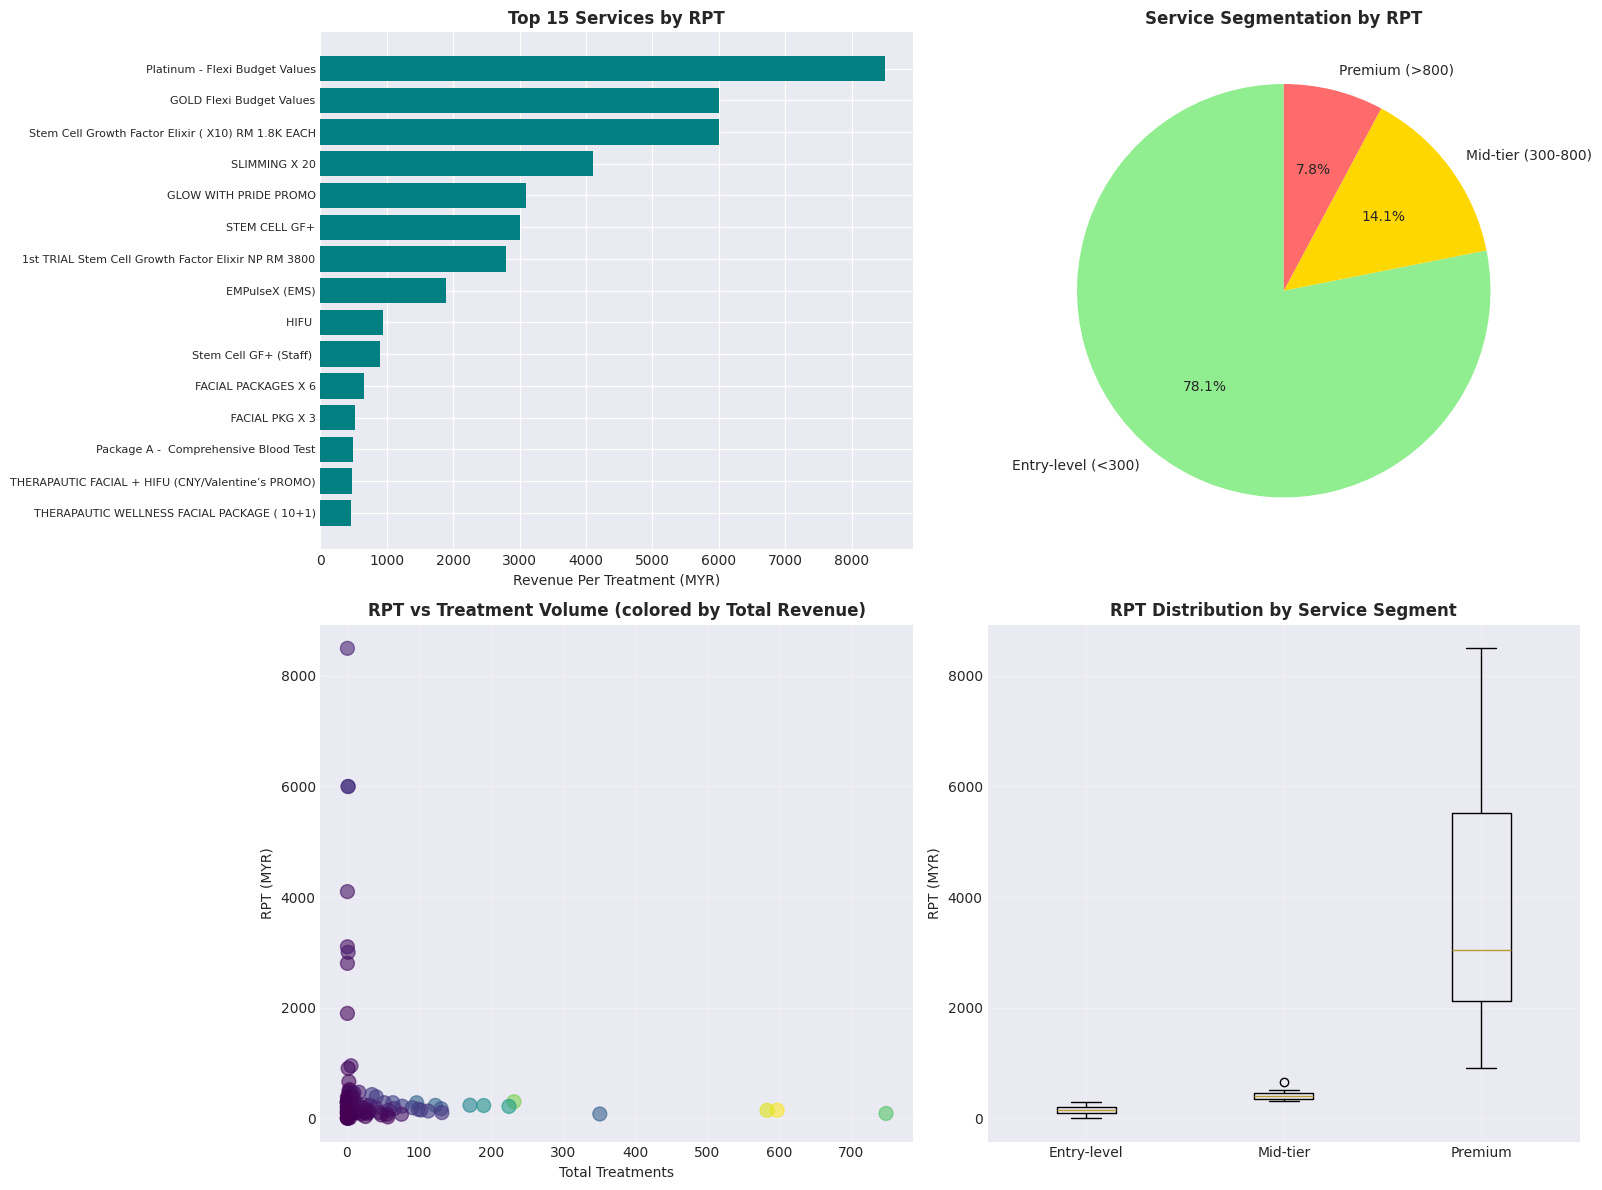

✓ RPT analysis visualizations saved!


In [44]:
# Visualize RPT distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top 15 Services by RPT
top_15 = rpt_by_service.head(15)
axes[0, 0].barh(range(len(top_15)), top_15['RPT'], color='teal')
axes[0, 0].set_yticks(range(len(top_15)))
axes[0, 0].set_yticklabels(top_15['Service'], fontsize=8)
axes[0, 0].set_xlabel('Revenue Per Treatment (MYR)', fontsize=10)
axes[0, 0].set_title('Top 15 Services by RPT', fontsize=12, fontweight='bold')
axes[0, 0].invert_yaxis()

# 2. RPT Distribution by Segment
segment_counts = rpt_by_service['Segment'].value_counts()
colors = ['#90EE90', '#FFD700', '#FF6B6B']
axes[0, 1].pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', 
               colors=colors, startangle=90)
axes[0, 1].set_title('Service Segmentation by RPT', fontsize=12, fontweight='bold')

# 3. RPT vs Total Revenue (Scatter)
axes[1, 0].scatter(rpt_by_service['Total_Treatments'], rpt_by_service['RPT'], 
                   alpha=0.6, c=rpt_by_service['Total_Revenue'], cmap='viridis', s=100)
axes[1, 0].set_xlabel('Total Treatments', fontsize=10)
axes[1, 0].set_ylabel('RPT (MYR)', fontsize=10)
axes[1, 0].set_title('RPT vs Treatment Volume (colored by Total Revenue)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Box plot of RPT by Segment
segment_data = [rpt_by_service[rpt_by_service['Segment'] == seg]['RPT'].values 
                for seg in ['Entry-level (<300)', 'Mid-tier (300-800)', 'Premium (>800)']]
axes[1, 1].boxplot(segment_data, labels=['Entry-level', 'Mid-tier', 'Premium'])
axes[1, 1].set_ylabel('RPT (MYR)', fontsize=10)
axes[1, 1].set_title('RPT Distribution by Service Segment', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/rpt_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ RPT analysis visualizations saved!")

## 5. Time Series Analysis

In [45]:
# Create daily revenue time series
print("Creating daily revenue time series...\n")

# Aggregate daily revenue from Daily Received
daily_revenue = daily_received_clean.groupby('Date').agg({
    'Sale Total (MYR)': 'sum',
    'Reference No.': 'count'
}).reset_index()

daily_revenue.columns = ['Date', 'Revenue', 'Transaction_Count']
daily_revenue = daily_revenue.sort_values('Date')

# Remove any remaining NaN
daily_revenue = daily_revenue.dropna(subset=['Date', 'Revenue'])

print(f"Daily Revenue Summary:")
print(f"  Date range: {daily_revenue['Date'].min()} to {daily_revenue['Date'].max()}")
print(f"  Total days: {len(daily_revenue)}")
print(f"  Total revenue: {daily_revenue['Revenue'].sum():,.2f} MYR")
print(f"  Average daily revenue: {daily_revenue['Revenue'].mean():,.2f} MYR")
print(f"  Median daily revenue: {daily_revenue['Revenue'].median():,.2f} MYR")
print(f"\nRevenue Statistics:")
print(daily_revenue['Revenue'].describe())

Creating daily revenue time series...

Daily Revenue Summary:
  Date range: 2021-01-06 00:00:00 to 2025-11-15 00:00:00
  Total days: 1276
  Total revenue: 3,800,239.90 MYR
  Average daily revenue: 2,978.24 MYR
  Median daily revenue: 1,441.00 MYR

Revenue Statistics:
count     1276.000000
mean      2978.244436
std       4413.960184
min     -42346.600000
25%        437.500000
50%       1441.000000
75%       4181.000000
max      47416.000000
Name: Revenue, dtype: float64


In [46]:
# Add time-based features for analysis
daily_revenue['Year'] = daily_revenue['Date'].dt.year
daily_revenue['Month'] = daily_revenue['Date'].dt.month
daily_revenue['Month_Name'] = daily_revenue['Date'].dt.strftime('%B')
daily_revenue['Day_of_Week'] = daily_revenue['Date'].dt.dayofweek
daily_revenue['Day_Name'] = daily_revenue['Date'].dt.strftime('%A')
daily_revenue['Quarter'] = daily_revenue['Date'].dt.quarter
daily_revenue['Is_Weekend'] = daily_revenue['Day_of_Week'].isin([5, 6]).astype(int)

# Calculate 7-day and 30-day moving averages
daily_revenue['MA_7'] = daily_revenue['Revenue'].rolling(window=7, min_periods=1).mean()
daily_revenue['MA_30'] = daily_revenue['Revenue'].rolling(window=30, min_periods=1).mean()

print("✓ Time-based features added!")
print(f"\nSample of daily revenue data:")
print(daily_revenue.head())

✓ Time-based features added!

Sample of daily revenue data:
        Date  Revenue  Transaction_Count  Year  Month Month_Name  Day_of_Week  \
0 2021-01-06    760.0                  2  2021      1    January            2   
1 2021-10-07   1160.0                  1  2021     10    October            3   
2 2021-10-09   5448.0                  3  2021     10    October            5   
3 2021-10-10   1360.0                  2  2021     10    October            6   
4 2021-10-11    760.0                  1  2021     10    October            0   

    Day_Name  Quarter  Is_Weekend    MA_7   MA_30  
0  Wednesday        1           0   760.0   760.0  
1   Thursday        4           0   960.0   960.0  
2   Saturday        4           1  2456.0  2456.0  
3     Sunday        4           1  2182.0  2182.0  
4     Monday        4           0  1897.6  1897.6  


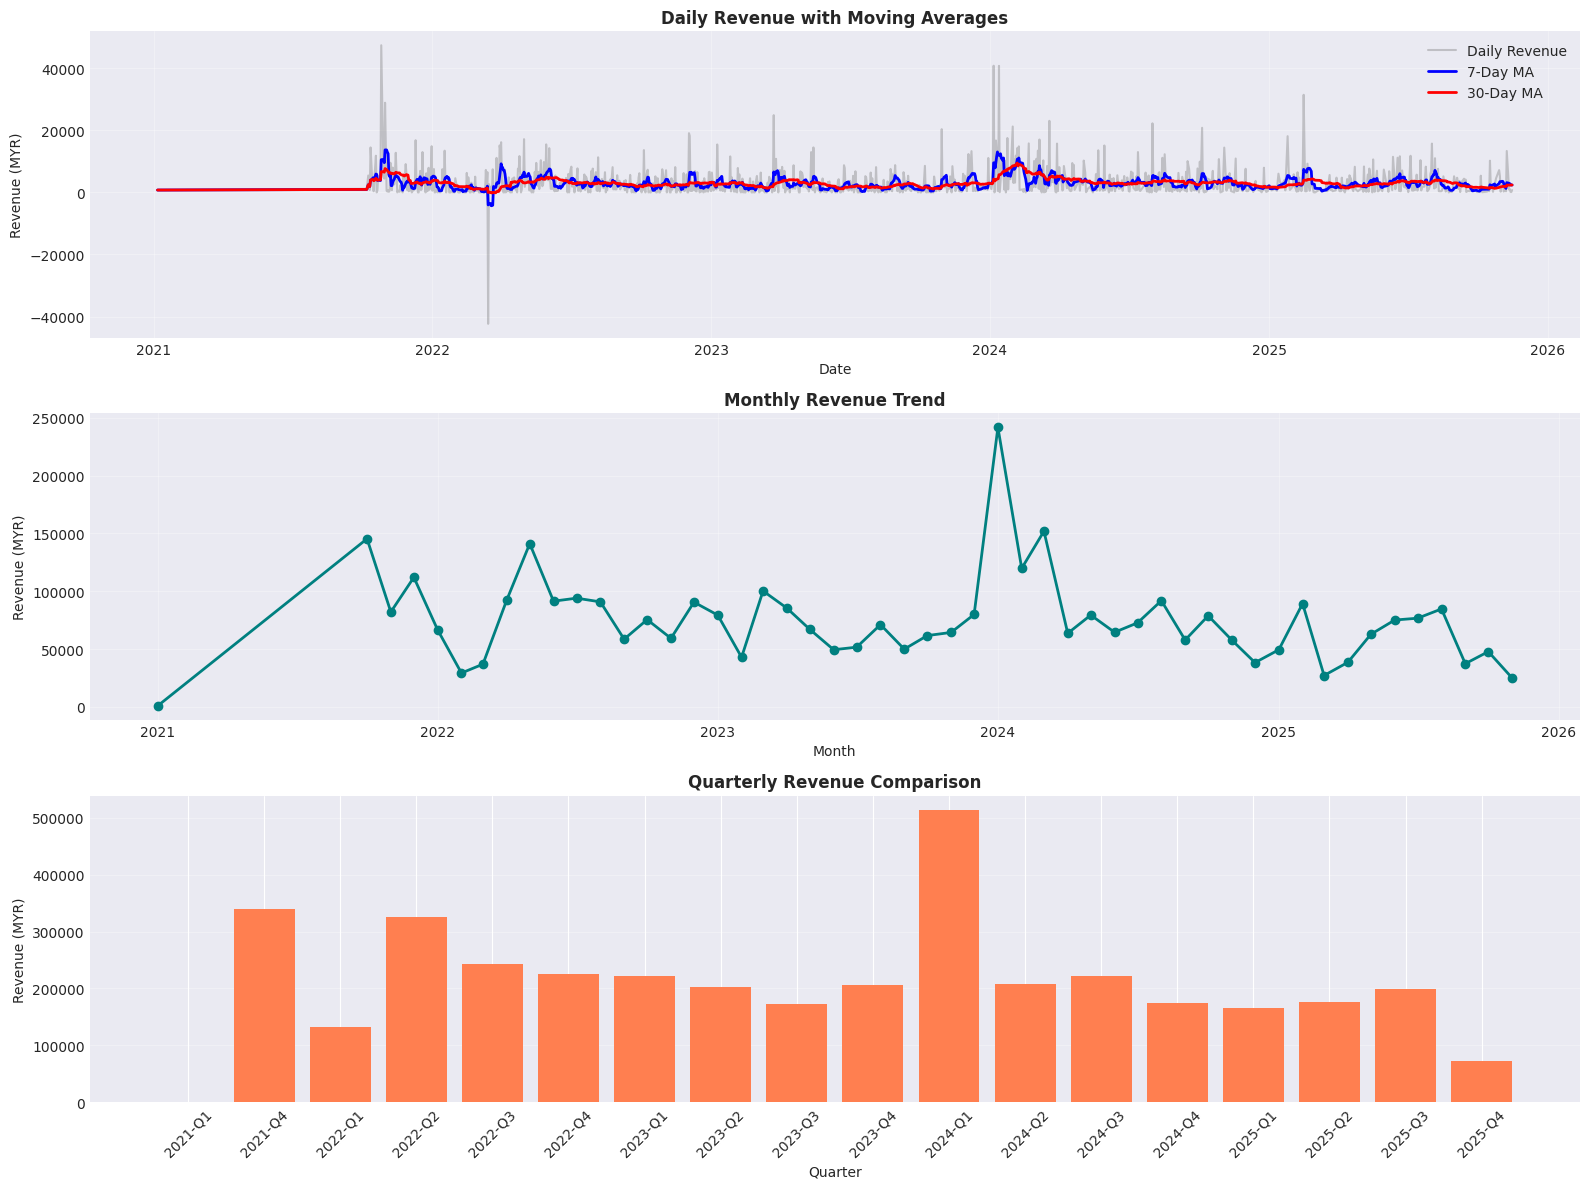

✓ Revenue trend visualizations saved!


In [47]:
# Visualize daily revenue trends
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# 1. Daily Revenue with Moving Averages
axes[0].plot(daily_revenue['Date'], daily_revenue['Revenue'], alpha=0.4, label='Daily Revenue', color='gray')
axes[0].plot(daily_revenue['Date'], daily_revenue['MA_7'], label='7-Day MA', color='blue', linewidth=2)
axes[0].plot(daily_revenue['Date'], daily_revenue['MA_30'], label='30-Day MA', color='red', linewidth=2)
axes[0].set_xlabel('Date', fontsize=10)
axes[0].set_ylabel('Revenue (MYR)', fontsize=10)
axes[0].set_title('Daily Revenue with Moving Averages', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Monthly Revenue Trend
monthly_revenue = daily_revenue.groupby(['Year', 'Month'])['Revenue'].sum().reset_index()
monthly_revenue['Date'] = pd.to_datetime(monthly_revenue[['Year', 'Month']].assign(day=1))
axes[1].plot(monthly_revenue['Date'], monthly_revenue['Revenue'], marker='o', linewidth=2, color='teal')
axes[1].set_xlabel('Month', fontsize=10)
axes[1].set_ylabel('Revenue (MYR)', fontsize=10)
axes[1].set_title('Monthly Revenue Trend', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# 3. Quarterly Revenue Comparison
quarterly_revenue = daily_revenue.groupby(['Year', 'Quarter'])['Revenue'].sum().reset_index()
quarterly_revenue['Year_Quarter'] = quarterly_revenue['Year'].astype(str) + '-Q' + quarterly_revenue['Quarter'].astype(str)
axes[2].bar(range(len(quarterly_revenue)), quarterly_revenue['Revenue'], color='coral')
axes[2].set_xticks(range(len(quarterly_revenue)))
axes[2].set_xticklabels(quarterly_revenue['Year_Quarter'], rotation=45)
axes[2].set_xlabel('Quarter', fontsize=10)
axes[2].set_ylabel('Revenue (MYR)', fontsize=10)
axes[2].set_title('Quarterly Revenue Comparison', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/figures/revenue_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Revenue trend visualizations saved!")

## 6. Seasonal and Weekly Patterns

In [48]:
# Analyze weekly and monthly patterns
print("Analyzing seasonal and weekly patterns...\n")

# Average revenue by day of week
day_of_week_revenue = daily_revenue.groupby('Day_Name')['Revenue'].agg(['mean', 'sum', 'count']).reset_index()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_of_week_revenue['Day_Name'] = pd.Categorical(day_of_week_revenue['Day_Name'], categories=day_order, ordered=True)
day_of_week_revenue = day_of_week_revenue.sort_values('Day_Name')

print("Average Revenue by Day of Week:")
print(day_of_week_revenue)

# Average revenue by month
month_revenue = daily_revenue.groupby('Month_Name')['Revenue'].agg(['mean', 'sum', 'count']).reset_index()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
month_revenue['Month_Name'] = pd.Categorical(month_revenue['Month_Name'], categories=month_order, ordered=True)
month_revenue = month_revenue.sort_values('Month_Name')

print("\nAverage Revenue by Month:")
print(month_revenue)

# Weekend vs Weekday comparison
weekend_comparison = daily_revenue.groupby('Is_Weekend')['Revenue'].agg(['mean', 'median', 'sum', 'count']).reset_index()
weekend_comparison['Is_Weekend'] = weekend_comparison['Is_Weekend'].map({0: 'Weekday', 1: 'Weekend'})

print("\nWeekend vs Weekday Revenue:")
print(weekend_comparison)

Analyzing seasonal and weekly patterns...

Average Revenue by Day of Week:
    Day_Name         mean       sum  count
1     Monday  3144.603636  518859.6    165
5    Tuesday  2147.239080  373619.6    174
6  Wednesday  2791.639227  505286.7    181
4   Thursday  2533.897222  456101.5    180
0     Friday  2971.745355  543829.4    183
2   Saturday  4039.899505  816059.7    202
3     Sunday  3070.593717  586483.4    191

Average Revenue by Month:
   Month_Name         mean       sum  count
4     January  4333.229703  437656.2    101
3    February  2959.917895  281192.2     95
7       March  2848.240541  316154.7    111
0       April  3008.989247  279836.0     93
8         May  3367.142308  350182.8    104
6        June  2722.047573  280370.9    103
5        July  2681.360000  294949.6    110
1      August  3021.605357  338419.8    112
11  September  2015.531683  203568.7    101
10    October  3324.655285  408932.6    123
9    November  2573.841071  288270.2    112
2    December  2889.245045

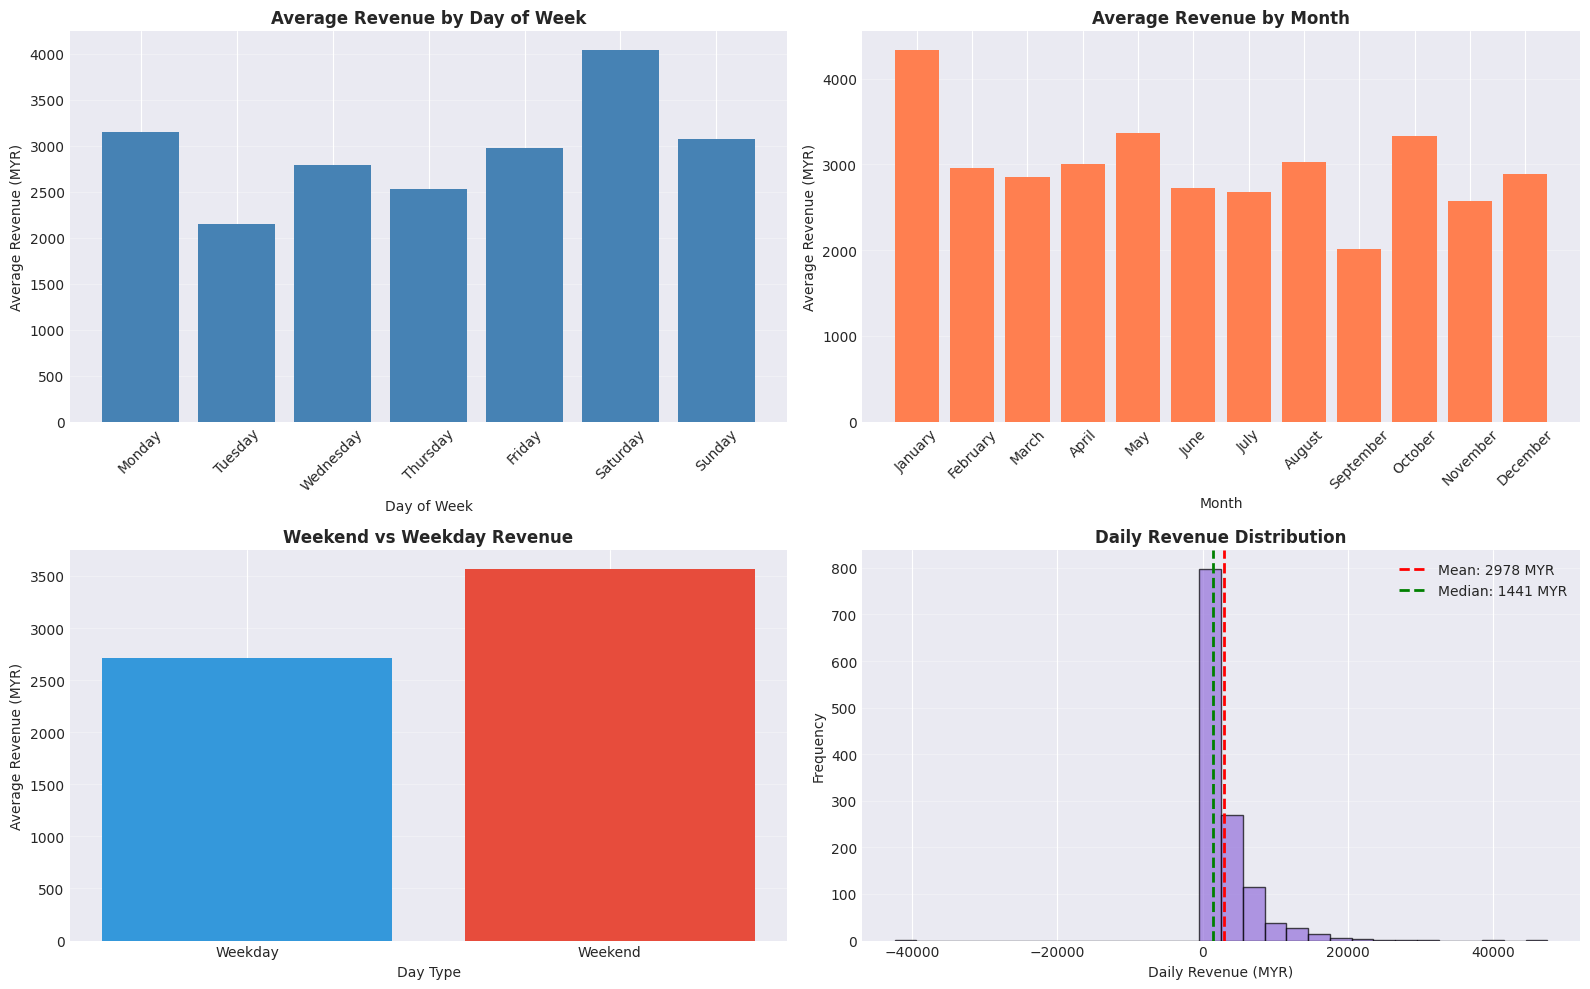

✓ Seasonal pattern visualizations saved!


In [49]:
# Additional pattern visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Average Revenue by Day of Week
axes[0, 0].bar(day_of_week_revenue['Day_Name'], day_of_week_revenue['mean'], color='steelblue')
axes[0, 0].set_xlabel('Day of Week', fontsize=10)
axes[0, 0].set_ylabel('Average Revenue (MYR)', fontsize=10)
axes[0, 0].set_title('Average Revenue by Day of Week', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Average Revenue by Month
axes[0, 1].bar(month_revenue['Month_Name'], month_revenue['mean'], color='coral')
axes[0, 1].set_xlabel('Month', fontsize=10)
axes[0, 1].set_ylabel('Average Revenue (MYR)', fontsize=10)
axes[0, 1].set_title('Average Revenue by Month', fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Weekend vs Weekday Comparison
axes[1, 0].bar(weekend_comparison['Is_Weekend'], weekend_comparison['mean'], 
               color=['#3498db', '#e74c3c'])
axes[1, 0].set_xlabel('Day Type', fontsize=10)
axes[1, 0].set_ylabel('Average Revenue (MYR)', fontsize=10)
axes[1, 0].set_title('Weekend vs Weekday Revenue', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Revenue Distribution
axes[1, 1].hist(daily_revenue['Revenue'], bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(daily_revenue['Revenue'].mean(), color='red', 
                   linestyle='--', linewidth=2, label=f"Mean: {daily_revenue['Revenue'].mean():.0f} MYR")
axes[1, 1].axvline(daily_revenue['Revenue'].median(), color='green', 
                   linestyle='--', linewidth=2, label=f"Median: {daily_revenue['Revenue'].median():.0f} MYR")
axes[1, 1].set_xlabel('Daily Revenue (MYR)', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].set_title('Daily Revenue Distribution', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/figures/seasonal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Seasonal pattern visualizations saved!")

## 7. Service Category Performance

Analyzing service category performance...

Service Category Performance:
             Category  Total_Revenue  Total_Treatments  Transaction_Count  \
4              FACIAL      356292.41            1785.0                891   
7            SLIMMING      198741.20            1861.0               1056   
0           1ST TRIAL      149644.50             766.0                496   
9                 TCM       57184.00             440.0                181   
5        FLEXI BUDGET       22615.00              84.0                 49   
2       EYE TREATMENT       17871.00             110.0                 44   
1           BODY CARE        4098.00               1.0                  1   
8       STEM CELL GF+        1800.00               2.0                  2   
6    SKIN TAG REMOVAL        1220.00              57.0                  9   
10       TCM + FACIAL         376.00               2.0                  2   
3   EYELASH EXTENSION         138.00               1.0                  1   

  

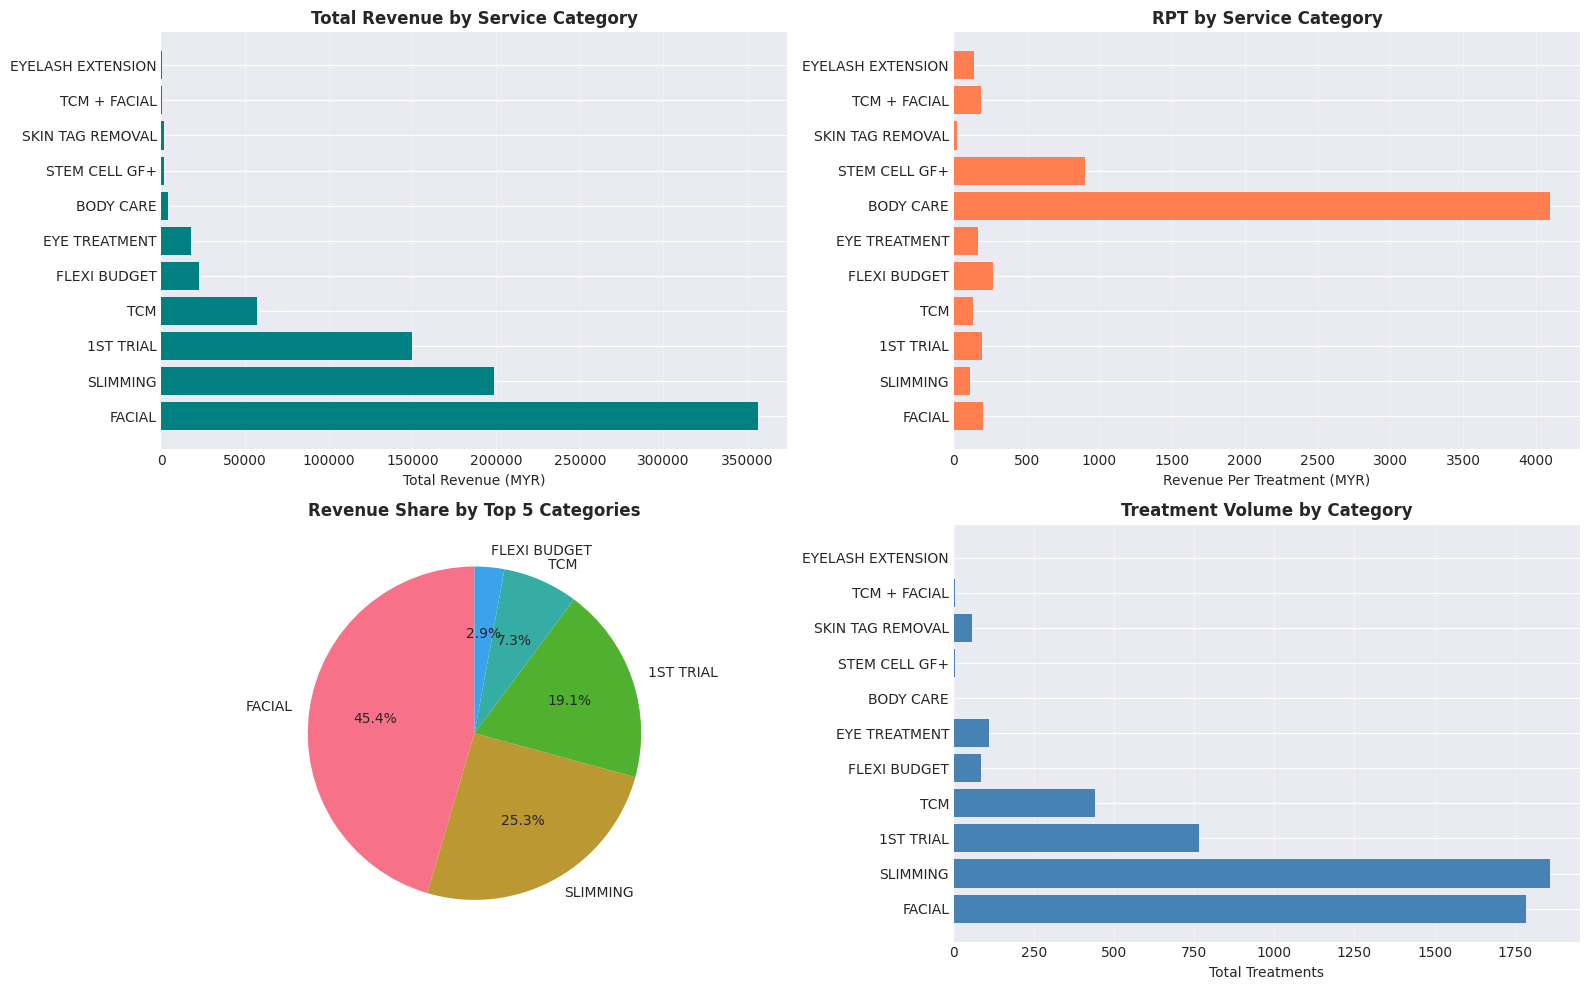


✓ Category performance visualizations saved!


In [50]:
# Analyze performance by service category
print("Analyzing service category performance...\n")

# Merge with service list to get categories
services_with_category = services_only.merge(
    service_list_clean[['Code', 'Section', 'Category']],
    left_on='Item Code',
    right_on='Code',
    how='left'
)

# Analyze by Section (main category)
category_performance = services_with_category.groupby('Section').agg({
    'Total (MYR)': 'sum',
    'Qty': 'sum',
    'Reference No.': 'count'
}).reset_index()

category_performance.columns = ['Category', 'Total_Revenue', 'Total_Treatments', 'Transaction_Count']
category_performance['RPT'] = category_performance['Total_Revenue'] / category_performance['Total_Treatments']
category_performance['Revenue_Share'] = (category_performance['Total_Revenue'] / category_performance['Total_Revenue'].sum()) * 100

category_performance = category_performance.sort_values('Total_Revenue', ascending=False)

print("Service Category Performance:")
print(category_performance)

# Visualize category performance
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Revenue by Category
axes[0, 0].barh(category_performance['Category'], category_performance['Total_Revenue'], color='teal')
axes[0, 0].set_xlabel('Total Revenue (MYR)', fontsize=10)
axes[0, 0].set_title('Total Revenue by Service Category', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2. RPT by Category
axes[0, 1].barh(category_performance['Category'], category_performance['RPT'], color='coral')
axes[0, 1].set_xlabel('Revenue Per Treatment (MYR)', fontsize=10)
axes[0, 1].set_title('RPT by Service Category', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. Revenue Share (Pie Chart)
top_categories = category_performance.head(5)
axes[1, 0].pie(top_categories['Total_Revenue'], labels=top_categories['Category'], 
               autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Revenue Share by Top 5 Categories', fontsize=12, fontweight='bold')

# 4. Treatment Volume by Category
axes[1, 1].barh(category_performance['Category'], category_performance['Total_Treatments'], color='steelblue')
axes[1, 1].set_xlabel('Total Treatments', fontsize=10)
axes[1, 1].set_title('Treatment Volume by Category', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../outputs/figures/category_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Category performance visualizations saved!")

## 8. Customer and Employee Analysis

In [51]:
# Customer analysis
print("Analyzing customer behavior...\n")

customer_analysis = sale_ticket_clean.groupby('Customer').agg({
    'Total (MYR)': 'sum',
    'Reference No.': 'nunique',
    'Date': ['min', 'max']
}).reset_index()

customer_analysis.columns = ['Customer', 'Total_Spending', 'Transaction_Count', 'First_Visit', 'Last_Visit']
customer_analysis['Avg_Transaction_Value'] = customer_analysis['Total_Spending'] / customer_analysis['Transaction_Count']
customer_analysis = customer_analysis.sort_values('Total_Spending', ascending=False)

print("Top 10 Customers by Spending:")
print(customer_analysis.head(10)[['Customer', 'Total_Spending', 'Transaction_Count', 'Avg_Transaction_Value']])

print(f"\nCustomer Summary:")
print(f"  Total unique customers: {len(customer_analysis)}")
print(f"  Average spending per customer: {customer_analysis['Total_Spending'].mean():.2f} MYR")
print(f"  Average transactions per customer: {customer_analysis['Transaction_Count'].mean():.2f}")

# Employee performance
print("\n" + "="*60)
print("Analyzing employee performance...\n")

employee_performance = sale_ticket_clean[sale_ticket_clean['Employee'].notna()].groupby('Employee').agg({
    'Total (MYR)': 'sum',
    'Reference No.': 'nunique'
}).reset_index()

employee_performance.columns = ['Employee', 'Total_Sales', 'Transaction_Count']
employee_performance['Avg_Transaction_Value'] = employee_performance['Total_Sales'] / employee_performance['Transaction_Count']
employee_performance = employee_performance.sort_values('Total_Sales', ascending=False)

print("Employee Performance:")
print(employee_performance)

Analyzing customer behavior...

Top 10 Customers by Spending:
                Customer  Total_Spending  Transaction_Count  \
549                MEERA         58689.0                 68   
760          ROSSA NAVET         24453.2                 18   
608            NANCY BAN         20887.4                 26   
631  NOOR AZRAHANY OSMAN         18344.0                  6   
759      ROSLAN BIN OMAR         17304.0                 22   
65            ANDREA BAN         16106.0                 13   
149         CAROLINE TAN         15460.0                 27   
559         MICHELLE TAY         15353.6                 18   
553           MELVIN LOH         15166.0                 19   
548             MDM RUBY         13466.0                 45   

     Avg_Transaction_Value  
549             863.073529  
760            1358.511111  
608             803.361538  
631            3057.333333  
759             786.545455  
65             1238.923077  
149             572.592593  
559         

## 9. Save Cleaned Data

In [52]:
# Save cleaned datasets for use in subsequent notebooks
print("Saving cleaned data...\n")

# Create processed data directory
import os
os.makedirs('../data/processed', exist_ok=True)

# Save cleaned datasets
daily_received_clean.to_csv('../data/processed/daily_received_clean.csv', index=False)
sale_ticket_clean.to_csv('../data/processed/sale_ticket_clean.csv', index=False)
service_list_clean.to_csv('../data/processed/service_list_clean.csv', index=False)
daily_revenue.to_csv('../data/processed/daily_revenue.csv', index=False)
rpt_by_service.to_csv('../data/processed/rpt_by_service.csv', index=False)
customer_analysis.to_csv('../data/processed/customer_analysis.csv', index=False)
employee_performance.to_csv('../data/processed/employee_performance.csv', index=False)

print("✓ All cleaned data saved to '../data/processed/' directory")
print("\nFiles saved:")
print("  - daily_received_clean.csv")
print("  - sale_ticket_clean.csv")
print("  - service_list_clean.csv")
print("  - daily_revenue.csv")
print("  - rpt_by_service.csv")
print("  - customer_analysis.csv")
print("  - employee_performance.csv")

Saving cleaned data...

✓ All cleaned data saved to '../data/processed/' directory

Files saved:
  - daily_received_clean.csv
  - sale_ticket_clean.csv
  - service_list_clean.csv
  - daily_revenue.csv
  - rpt_by_service.csv
  - customer_analysis.csv
  - employee_performance.csv
✓ All cleaned data saved to '../data/processed/' directory

Files saved:
  - daily_received_clean.csv
  - sale_ticket_clean.csv
  - service_list_clean.csv
  - daily_revenue.csv
  - rpt_by_service.csv
  - customer_analysis.csv
  - employee_performance.csv


## 10. Summary and Key Findings

In [53]:
print("="*80)
print("EDA SUMMARY - KEY FINDINGS")
print("="*80)

print("\n1. REVENUE OVERVIEW")
print(f"   • Total Revenue: {daily_revenue['Revenue'].sum():,.2f} MYR")
print(f"   • Average Daily Revenue: {daily_revenue['Revenue'].mean():,.2f} MYR")
print(f"   • Total Transactions: {len(sale_ticket_clean['Reference No.'].unique())}")
print(f"   • Date Range: {daily_revenue['Date'].min()} to {daily_revenue['Date'].max()}")

print("\n2. RPT ANALYSIS")
print(f"   • Average RPT: {rpt_by_service['RPT'].mean():.2f} MYR")
print(f"   • Highest RPT Service: {rpt_by_service.iloc[0]['Service']} ({rpt_by_service.iloc[0]['RPT']:.2f} MYR)")
print(f"   • Service Segments: {rpt_by_service['Segment'].value_counts().to_dict()}")

print("\n3. TEMPORAL PATTERNS")
print(f"   • Highest Revenue Day: {day_of_week_revenue.iloc[day_of_week_revenue['mean'].argmax()]['Day_Name']}")
print(f"   • Lowest Revenue Day: {day_of_week_revenue.iloc[day_of_week_revenue['mean'].argmin()]['Day_Name']}")
print(f"   • Weekend vs Weekday: {weekend_comparison['mean'].iloc[1]:.2f} vs {weekend_comparison['mean'].iloc[0]:.2f} MYR")
print(f"   • Highest Revenue Month: {month_revenue.iloc[month_revenue['mean'].argmax()]['Month_Name']}")

print("\n4. CUSTOMER INSIGHTS")
print(f"   • Total Unique Customers: {len(customer_analysis)}")
print(f"   • Average Customer Spending: {customer_analysis['Total_Spending'].mean():.2f} MYR")
print(f"   • Average Transactions per Customer: {customer_analysis['Transaction_Count'].mean():.2f}")
print(f"   • Top Customer Spending: {customer_analysis.iloc[0]['Total_Spending']:.2f} MYR")

print("\n5. EMPLOYEE PERFORMANCE")
print(f"   • Number of Employees: {len(employee_performance)}")
print(f"   • Top Performer: {employee_performance.iloc[0]['Employee']} ({employee_performance.iloc[0]['Total_Sales']:.2f} MYR)")

print("\n6. SERVICE CATEGORIES")
print(f"   • Top Revenue Category: {category_performance.iloc[0]['Category']} ({category_performance.iloc[0]['Revenue_Share']:.1f}%)")
print(f"   • Highest RPT Category: {category_performance.iloc[category_performance['RPT'].argmax()]['Category']}")

print("\n" + "="*80)
print("✓ Part 1.1: Data Understanding & EDA COMPLETE")
print("="*80)

EDA SUMMARY - KEY FINDINGS

1. REVENUE OVERVIEW
   • Total Revenue: 3,800,239.90 MYR
   • Average Daily Revenue: 2,978.24 MYR
   • Total Transactions: 3820
   • Date Range: 2021-01-06 00:00:00 to 2025-11-15 00:00:00

2. RPT ANALYSIS
   • Average RPT: 470.31 MYR
   • Highest RPT Service: Platinum - Flexi Budget Values (8500.00 MYR)
   • Service Segments: {'Entry-level (<300)': 100, 'Mid-tier (300-800)': 18, 'Premium (>800)': 10}

3. TEMPORAL PATTERNS
   • Highest Revenue Day: Saturday
   • Lowest Revenue Day: Tuesday
   • Weekend vs Weekday: 3568.81 vs 2715.40 MYR
   • Highest Revenue Month: January

4. CUSTOMER INSIGHTS
   • Total Unique Customers: 1012
   • Average Customer Spending: 1159.20 MYR
   • Average Transactions per Customer: 3.77
   • Top Customer Spending: 58689.00 MYR

5. EMPLOYEE PERFORMANCE
   • Number of Employees: 43
   • Top Performer: Yumi Tan (434983.74 MYR)

6. SERVICE CATEGORIES
   • Top Revenue Category: FACIAL (44.0%)
   • Highest RPT Category: BODY CARE

✓ Part